In [163]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import requests
from shapely.geometry import shape
from shapely.geometry import Polygon, LineString, MultiLineString, MultiPolygon
from shapely.ops import polygonize, unary_union
import osmnx as ox
%matplotlib inline
pd.set_option('display.max_columns', None)  # Show all columns

In [30]:
parks_dataset_iteration1 = gpd.read_file("natural_assets_data_processed/natural_assets.gpkg")

In [ ]:
uk_boundaries = gpd.read_file("natural_assets_data_raw/uk_boundaries.gpkg")
uk_union = uk_boundaries.union_all()
if isinstance(uk_union, MultiPolygon):
    largest_poly = max(uk_union.geoms, key=lambda x: x.area)
else:
    largest_poly = uk_union

buffered_poly = largest_poly.buffer(200)
uk_largest_polygon = gpd.GeoDataFrame(geometry=[buffered_poly], crs=uk_boundaries.crs)
mainland_geom = uk_largest_polygon.union_all()

# Combining SSSIs

In [2]:
existing_dataset = gpd.read_file("natural_assets_data_processed/natural_assets.gpkg")
sssi_england = gpd.read_file("natural_assets_data_raw/sssi/SSSI_England_8892003304773496568.gpkg")
sssi_wales = gpd.read_file("natural_assets_data_raw/sssi/NRW_SSSI.gpkg")
sssi_scotland = gpd.read_file("natural_assets_data_raw/sssi/SSSI_SCOTLAND.gpkg")

In [3]:
name_column_eng = 'SSSI_NAME'
name_column_wales = 'sssi_name'
name_column_scotland = 'NAME'

# Dissolve polygons based on the name field
sssi_england_dissolved = sssi_england.dissolve(by=name_column_eng)
sssi_wales_dissolved = sssi_wales.dissolve(by=name_column_wales)
sssi_scotland_dissolved = sssi_scotland.dissolve(by=name_column_scotland)

# Reset index if you want to make 'NAME' a column again
sssi_england_dissolved = sssi_england_dissolved.reset_index()
sssi_wales_dissolved = sssi_wales_dissolved.reset_index()
sssi_scotland_dissolved = sssi_scotland_dissolved.reset_index()

sssi_scotland_dissolved = sssi_scotland_dissolved[sssi_scotland_dissolved["GEOGRAPHIC"] != "MARINE"].reset_index()

In [19]:
sssi_combined = pd.concat([sssi_scotland_dissolved, sssi_england_dissolved, sssi_wales_dissolved], ignore_index=True)

# Fill missing NAME values with sssi_name values
sssi_combined["NAME"] = sssi_combined["NAME"].fillna(sssi_combined["sssi_name"])
sssi_combined["NAME"] = sssi_combined["NAME"].fillna(sssi_combined["SSSI_NAME"])

In [22]:
sssi_combined["NAME"].isna().value_counts()

NAME
False    6613
Name: count, dtype: int64

In [26]:
# Calculate intersection area and keep only those overlapping ≥ 10%
sssi_combined["overlap_ratio"] = (sssi_combined.geometry.intersection(mainland_geom).area / sssi_combined.geometry.area)

# Filter for rows with at least 10% overlap
sssi_combined = sssi_combined[sssi_combined["overlap_ratio"] >= 0.8].drop(columns="overlap_ratio")

In [28]:
sssi_combined_over10ha = sssi_combined[sssi_combined.geometry.area > 100_000]

In [46]:
# Calculate intersection area and keep only those overlapping ≥ 10%
sssi_combined_over10ha["iter1_overlap_ratio"] = (
    sssi_combined_over10ha.geometry.intersection(parks_dataset_iteration1
                                                ).area / sssi_combined_over10ha.geometry.area)

sssi_combined_over10ha_ovrl_rmv = sssi_combined_over10ha[
    ~(sssi_combined_over10ha["iter1_overlap_ratio"] >= 0.6)
].drop(columns="iter1_overlap_ratio")

/tmp/ipykernel_4909/4289163809.py:3: UserWarning: The indices of the left and right GeoSeries' are not equal, and therefore they will be aligned (reordering and/or introducing missing values) before executing the operation. If this alignment is the desired behaviour, you can silence this warning by passing 'align=True'. If you don't want alignment and protect yourself of accidentally aligning, you can pass 'align=False'.
  sssi_combined_over10ha.geometry.intersection(parks_dataset_iteration1
/opt/conda/lib/python3.11/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [55]:
# removing overlap - deleting small parks within SSSI

# Ensure matching CRS
parks = parks_dataset_iteration1.to_crs("EPSG:27700").copy()
sssis = sssi_combined_over10ha_ovrl_rmv.to_crs("EPSG:27700")
parks["park_index"] = parks.index
intersections = gpd.overlay(parks, sssis, how="intersection")
intersections["overlap_area"] = intersections.geometry.area
overlap_sum = intersections.groupby("park_index")["overlap_area"].sum()

# Compute percent of each park overlapped by SSSIs
parks["overlap_percent"] = (overlap_sum / parks.geometry.area).reindex(parks.index).fillna(0) * 100
parks_ovrl_rmv = parks[~(parks["overlap_percent"] >= 40)]

In [62]:
# removing overlap - deleting small SSSI within parks

# Ensure matching CRS
sssis["sssi_index"] = sssis.index
intersections = gpd.overlay(parks_ovrl_rmv, sssis, how="intersection")
intersections["overlap_area"] = intersections.geometry.area
overlap_sum = intersections.groupby("sssi_index")["overlap_area"].sum()

# Compute percent of each park overlapped by SSSIs
sssis["overlap_percent"] = (overlap_sum / sssis.geometry.area).reindex(sssis.index).fillna(0) * 100
sssis_ovrl_rmv = sssis[~(sssis["overlap_percent"] >= 60)]

In [68]:
sssis_ovrl_rmv = sssis_ovrl_rmv[["NAME", "geometry"]]

In [70]:
# sssis_ovrl_rmv.to_file("natural_assets_data_raw/sssis_ovrl_rmv.gpkg", layer='sssis', driver="GPKG")
# parks_ovrl_rmv.to_file("natural_assets_data_raw/parks_ovrl_rmv.gpkg", layer='parks', driver="GPKG")

In [75]:
parks_ovrl_rmv = parks_ovrl_rmv[["name", "geometry", "website", "wikidata"]]

In [77]:
parks_dataset_iteration2 = pd.concat([parks_ovrl_rmv, sssis_ovrl_rmv], ignore_index=True)

In [83]:
parks_dataset_iteration2.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 8475 entries, 0 to 8474
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   name      4786 non-null   object  
 1   geometry  8475 non-null   geometry
 2   website   186 non-null    object  
 3   wikidata  318 non-null    object  
 4   NAME      3689 non-null   object  
dtypes: geometry(1), object(4)
memory usage: 331.2+ KB


In [88]:
parks_dataset_iteration2["geometry"].type.value_counts()

MultiPolygon    6116
Polygon         2359
Name: count, dtype: int64

### Buffering to join into simplified geometry

In [143]:
# # Set your buffer distance (small enough not to distort geometry)
# buffer_dist = 300

# # Copy to avoid modifying original
# parks_dataset_iteration2_buffered = parks_dataset_iteration2.copy()

# # Buffer, dissolve internal parts, and unbuffer back
# parks_dataset_iteration2_buffered["geometry"] = parks_dataset_iteration2_buffered["geometry"].apply(
#     lambda geom: (
#         geom.buffer(buffer_dist).buffer(-buffer_dist)
#         if isinstance(geom, MultiPolygon)
#         else geom
#     )
# )

In [144]:
# parks_dataset_iteration2_buffered["geometry"].type.value_counts()

Polygon         8043
MultiPolygon     432
Name: count, dtype: int64

In [145]:
# parks_dataset_iteration2_buffered.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 8475 entries, 0 to 8474
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   name      4786 non-null   object  
 1   geometry  8475 non-null   geometry
 2   website   186 non-null    object  
 3   wikidata  318 non-null    object  
 4   NAME      3689 non-null   object  
dtypes: geometry(1), object(4)
memory usage: 331.2+ KB


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


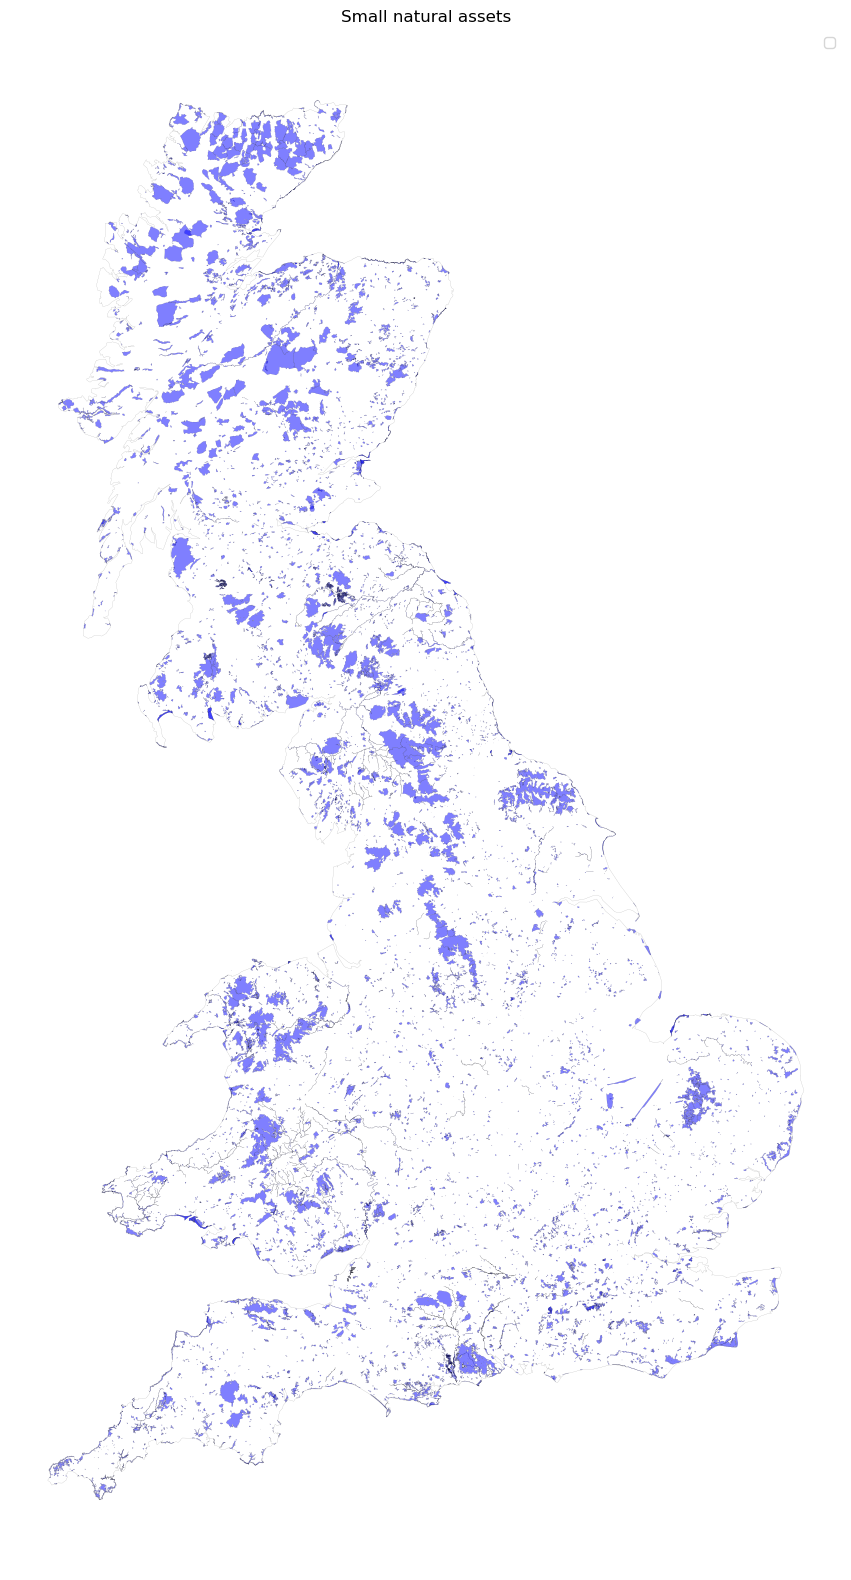

In [151]:
fig, ax = plt.subplots(figsize=(20, 20))

parks_dataset_iteration2.plot(ax=ax, facecolor="blue", linewidth=0.1, edgecolor="black", alpha=0.5)
uk_largest_polygon.plot(ax=ax, facecolor="none", linewidth=0.1, edgecolor="grey")
# parks_dataset_iteration2.plot(ax=ax, facecolor="none", linewidth=0.1, edgecolor="red")

plt.title("Small natural assets")
plt.legend()
plt.axis('off')
plt.show()

There are still overlapping features. removing in QGIS

In [154]:
parks_dataset_iteration2["name"] = parks_dataset_iteration2["name"].fillna(parks_dataset_iteration2["NAME"])
parks_dataset_iteration2 = parks_dataset_iteration2.drop(columns="NAME")

In [155]:
parks_dataset_iteration2.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 8475 entries, 0 to 8474
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   name      8475 non-null   object  
 1   geometry  8475 non-null   geometry
 2   website   186 non-null    object  
 3   wikidata  318 non-null    object  
dtypes: geometry(1), object(3)
memory usage: 265.0+ KB


In [160]:
parks_dataset_iteration2_drop = parks_dataset_iteration2.drop_duplicates(subset="name")

In [161]:
parks_dataset_iteration2_drop.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 7728 entries, 0 to 8474
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   name      7728 non-null   object  
 1   geometry  7728 non-null   geometry
 2   website   177 non-null    object  
 3   wikidata  281 non-null    object  
dtypes: geometry(1), object(3)
memory usage: 301.9+ KB


In [162]:
parks_dataset_iteration2_drop.to_file("natural_assets_data_raw/parks_dataset_iteration2.gpkg", layer='nature_assets', driver="GPKG")

# Geodiversity - Scotland and Wales

In [4]:
# Scotland geodiverse sites
scotland_geodiverse = sssi_scotland_dissolved[sssi_scotland_dissolved["TYPE"] == "GEOLOGICAL"].reset_index()

# Wales geodiverse sites (correcting the logical OR syntax and matching column name)
wales_geodiverse = sssi_wales_dissolved[
    (sssi_wales_dissolved["type"] == "Geological") | 
    (sssi_wales_dissolved["type"] == "Geological/M")
].reset_index()

geodiverse_combined = pd.concat([scotland_geodiverse, wales_geodiverse], ignore_index=True)

# Fill missing NAME values with sssi_name values
geodiverse_combined["NAME"] = geodiverse_combined["NAME"].fillna(geodiverse_combined["sssi_name"])
geodiverse_combined = geodiverse_combined[["NAME", "geometry"]]

In [8]:
# Calculate intersection area and keep only those overlapping ≥ 10%
geodiverse_combined["overlap_ratio"] = (
    geodiverse_combined.geometry.intersection(mainland_geom).area /
    geodiverse_combined.geometry.area
)

# Filter for rows with at least 10% overlap
geodiverse_combined = geodiverse_combined[
    geodiverse_combined["overlap_ratio"] >= 0.1
].drop(columns="overlap_ratio")

In [12]:
print(geodiverse_combined.crs)

EPSG:27700


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


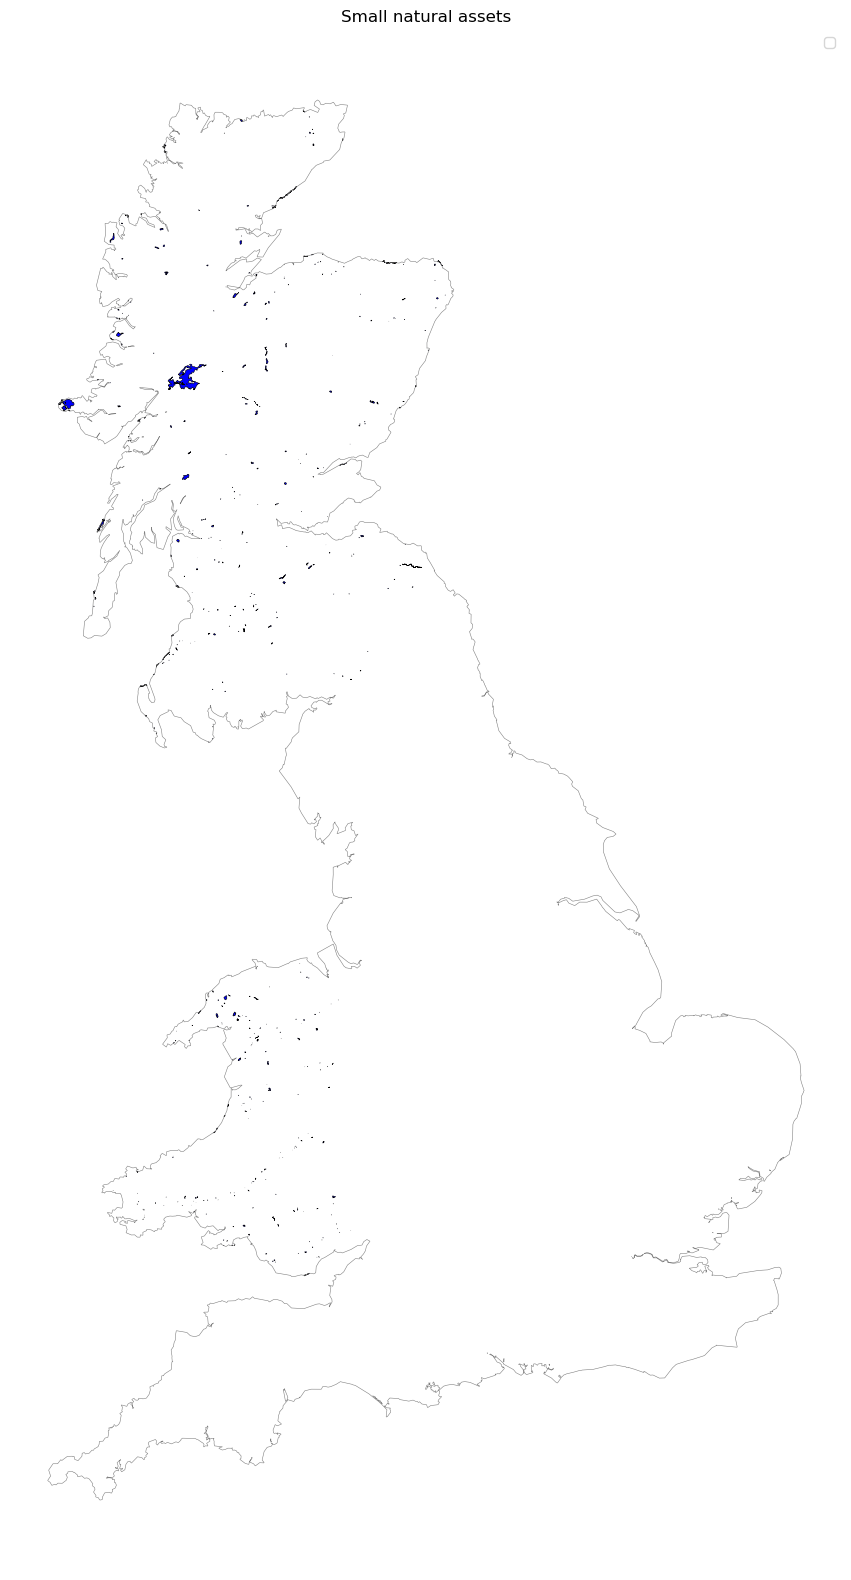

In [13]:
fig, ax = plt.subplots(figsize=(20, 20))

geodiverse_combined.plot(ax=ax, facecolor="blue", linewidth=0.4, edgecolor="black")
uk_largest_polygon.plot(ax=ax, facecolor="none", linewidth=0.4, edgecolor="grey")

plt.title("Small natural assets")
plt.legend()
plt.axis('off')
plt.show()

In [164]:
parks_dataset_iteration2 = gpd.read_file("natural_assets_data_raw/parks_dataset_iteration2.gpkg")

In [166]:
parks_dataset_iteration2 = parks_dataset_iteration2.to_crs("EPSG:4326")

In [168]:
parks_dataset_iteration2

,name,website,wikidata,geometry
0,Drum Sands,None,None,"MULTIPOLYGON (((-3.27215 55.98009, -3.27291 55..."
1,Sand Bay,None,Q7415759,"MULTIPOLYGON (((-2.9669 51.36359, -2.96693 51...."
2,Porth Beach,None,None,"MULTIPOLYGON (((-5.05653 50.42395, -5.05697 50..."
3,Watergate Beach,None,Q7974111,"MULTIPOLYGON (((-5.05268 50.43404, -5.05266 50..."
4,Mawgan Porth,None,None,"MULTIPOLYGON (((-5.03716 50.47229, -5.03696 50..."
...,...,...,...,...
7723,Ynys Uchaf,None,None,"MULTIPOLYGON (((-4.18807 51.81304, -4.18809 51..."
7724,Yr Arddu,None,None,"MULTIPOLYGON (((-4.03351 52.99918, -4.03351 52..."
7725,Yr Eifl,None,None,"MULTIPOLYGON (((-4.42261 52.97117, -4.42234 52..."
7726,Ysbyty Bron y Garth,None,None,"MULTIPOLYGON (((-4.0839 52.92513, -4.08381 52...."


In [181]:
from requests.exceptions import RequestException

In [ ]:
overlap_lengths = []
paths_all = gpd.GeoDataFrame()

for item, row in parks_dataset_iteration2.iterrows():
    polygon = row.geometry

    try:
        all_highways = ox.features_from_polygon(polygon, tags={"highway": True})
        paths = all_highways[all_highways['highway'].isin(['path', 'footway', 'track', 'pedestrian'])]
        # paths = ox.features_from_polygon(polygon, tags={"highway":["path", "footway","track", "pedestrian"]})
        if len(paths) == 0:
            raise ValueError(f"No paths found for {row['name']}.")
            
        paths_gdf = gpd.GeoDataFrame(paths, crs=parks_dataset_iteration2.crs)
        paths_gdf = paths_gdf[paths_gdf.geometry.type == 'LineString']
        paths_all = pd.concat([paths_all, paths_gdf], ignore_index=True)
        poly = gpd.GeoDataFrame([row], geometry=[polygon], crs=parks_dataset_iteration2.crs)
        intersections = gpd.overlay(poly, paths_gdf, how="intersection", keep_geom_type=False)
    
        if not intersections.empty:
            intersections = intersections.to_crs("EPSG:27700")
            intersections["overlap_length"] = intersections.geometry.length
            overlap_sum = intersections["overlap_length"].sum()
        else:
            overlap_sum = 0
            
    except (RequestException, ValueError) as e:
        print(f"Error processing polygon {item}: {e}")
        overlap_sum = 0  # If no paths are found or there's an error, set overlap_sum to 0
    
    overlap_lengths.append(overlap_sum)

paths_length_column = pd.DataFrame(overlap_lengths, columns=['overlap_length'])
paths_length_gdf = gpd.GeoDataFrame(paths_length_column, geometry=parks_dataset_iteration2.geometry)
paths_length_gdf.to_file("natural_assets_data_raw/length_paths.gpkg", layer='length_paths', driver="GPKG")

/opt/conda/lib/python3.11/site-packages/osmnx/features.py:718: FutureWarning: <class 'geopandas.array.GeometryArray'>._reduce will require a `keepdims` parameter in the future
  gdf = gdf[geom_filter & tags_filter].dropna(axis="columns", how="all")
/opt/conda/lib/python3.11/site-packages/osmnx/features.py:718: FutureWarning: <class 'geopandas.array.GeometryArray'>._reduce will require a `keepdims` parameter in the future
  gdf = gdf[geom_filter & tags_filter].dropna(axis="columns", how="all")


Error processing polygon 3: No matching features. Check query location, tags, and log.
Error processing polygon 4: No matching features. Check query location, tags, and log.
Error processing polygon 7: No matching features. Check query location, tags, and log.


/opt/conda/lib/python3.11/site-packages/osmnx/features.py:718: FutureWarning: <class 'geopandas.array.GeometryArray'>._reduce will require a `keepdims` parameter in the future
  gdf = gdf[geom_filter & tags_filter].dropna(axis="columns", how="all")


Error processing polygon 12: No matching features. Check query location, tags, and log.


/opt/conda/lib/python3.11/site-packages/osmnx/features.py:718: FutureWarning: <class 'geopandas.array.GeometryArray'>._reduce will require a `keepdims` parameter in the future
  gdf = gdf[geom_filter & tags_filter].dropna(axis="columns", how="all")
/opt/conda/lib/python3.11/site-packages/osmnx/features.py:718: FutureWarning: <class 'geopandas.array.GeometryArray'>._reduce will require a `keepdims` parameter in the future
  gdf = gdf[geom_filter & tags_filter].dropna(axis="columns", how="all")


...

Error processing polygon 2705: No matching features. Check query location, tags, and log.
Error processing polygon 2706: No matching features. Check query location, tags, and log.
Error processing polygon 2713: No matching features. Check query location, tags, and log.
Error processing polygon 2715: No matching features. Check query location, tags, and log.
Error processing polygon 2719: No matching features. Check query location, tags, and log.
Error processing polygon 2720: No paths found for Usselby Plantation.
Error processing polygon 2725: No matching features. Check query location, tags, and log.
Error processing polygon 2727: No matching features. Check query location, tags, and log.
Error processing polygon 2732: No matching features. Check query location, tags, and log.
Error processing polygon 2735: No matching features. Check query location, tags, and log.
Error processing polygon 2737: No matching features. Check query location, tags, and log.
Error processing polygon 2738:

/opt/conda/lib/python3.11/site-packages/osmnx/features.py:718: FutureWarning: <class 'geopandas.array.GeometryArray'>._reduce will require a `keepdims` parameter in the future
  gdf = gdf[geom_filter & tags_filter].dropna(axis="columns", how="all")


Error processing polygon 2750: No matching features. Check query location, tags, and log.


/opt/conda/lib/python3.11/site-packages/osmnx/features.py:718: FutureWarning: <class 'geopandas.array.GeometryArray'>._reduce will require a `keepdims` parameter in the future
  gdf = gdf[geom_filter & tags_filter].dropna(axis="columns", how="all")


Error processing polygon 2752: No matching features. Check query location, tags, and log.
Error processing polygon 2754: No matching features. Check query location, tags, and log.
Error processing polygon 2757: No paths found for North Wood.


In [ ]:
paths_all